In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi

import os
from IPython.display import Latex
from scipy import constants
import pandas as pd
from pandas import DataFrame
from time import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e


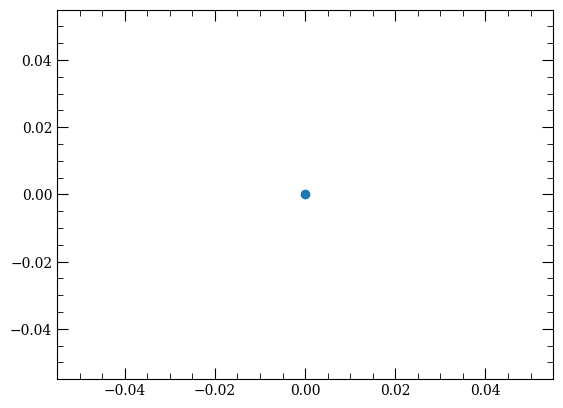

In [2]:
plt.figure()
plt.scatter([0], [0])
plt.show()

In [2]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()

l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2

j1_1 = 3/2
j2_1 = 3/2

n_dif = 3
jdif = 3
ldif = 3

b=0
energy_unit = 'MHz'


newpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\Stark Plots\\Rb\\{orbs[l1_0]}_{j1_0}, {orbs[l2_0]}_{j2_0}\\'
if not os.path.exists(newpath):
    os.makedirs(newpath)


In [3]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  \
0            7    45     0   0.5    47     0   0.5    45     1   1.5    46   
1            8    46     0   0.5    48     0   0.5    46     1   1.5    47   
2           11    48     0   0.5    51     0   0.5    48     1   1.5    50   
3            2    59     0   0.5    57     0   0.5    58     1   0.5    57   
4           12    61     0   0.5    65     0   0.5    61     1   0.5    64   
5            5    68     0   0.5    67     0   0.5    67     1   0.5    67   
6            6    69     0   0.5    68     0   0.5    68     1   0.5    68   
7            3    71     0   0.5    69     0   0.5    70     1   1.5    69   
8            4    72     0   0.5    70     0   0.5    71     1   1.5    70   
9            9    72     0   0.5    75     0   0.5    72     1   0.5    74   
10          10    73     0   0.5    76     0   0.5    73     1   0.5    75   
11          13    77     0   0.5    81     0   0.5    77     1  

c:\Users\Tommy\OneDrive - Durham University\level 4 Project\Code Directory\L4-code-directory-2\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


calculation of 5 values via perturbative approach: 9.9 s
calculation of 501 values via perturbative approach: 3.9 s


[]

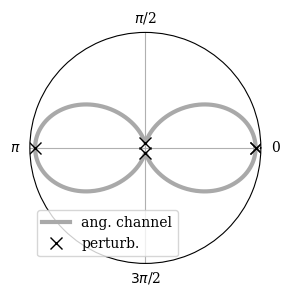

In [4]:
channel = 1
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

mj1, mj2 = j1, j2
l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1)
# set calculation propreties
nrange, dE = 10, 1 * 1e12
stateHop = False
energyDelta = 1e12
nValueRange = [20, 30]

# set theta values
theta_pert = np.linspace(0, np.pi*2, 5)
theta_lj = np.linspace(0, np.pi*2, 501)
phi = 0

# time array
times = []

# initialise PairStateInteractions class instance
calc = arc.PairStateInteractions(arc_atom1, n1, l1, j1, n2, l2, j2, m1=mj1, m2=mj2, interactionsUpTo=1, atom2 = arc_atom2)

# perturbative calculation
C6_pert = np.zeros_like(theta_pert)
times.append(time())
for i, theta in enumerate(theta_pert):
    C6_pert[i] = calc.getC6perturbatively(theta, phi, nrange, dE, degeneratePerturbation=False)
times.append(time())
print('calculation of {:.0f} values via perturbative approach: {:.1f} s'.format(len(theta_pert), times[1]-times[0]))

# angular channel code
times.append(time())
C6_lj = calc.getC6perturbatively_anglePairs([(theta, phi) for theta in theta_lj], nrange, dE, degeneratePerturbation=False, returnInteractionMatrix=False)[0]
times.append(time())
print('calculation of {:.0f} values via perturbative approach: {:.1f} s'.format(len(theta_lj), times[3]-times[2]))

# angular channel isolated
# status = calc.calculateAngularChannelData([l1, j1, mj1, arc_atom1], [l2, j2, mj2, arc_atom2], nValueRange, nrange, energyDelta, stateHopping=stateHop, overwriteLocalData=True)

# plot
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(1,1,1, projection='polar')

# plot
ax.plot(theta_lj, C6_lj, color='darkgray', linewidth=3, label='ang. channel')
ax.plot(theta_pert, C6_pert, color='black', linestyle='none', marker='x', ms=9, label='perturb.')
ax.legend(bbox_to_anchor=(0,0), loc=3)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2], ['0', r'$\pi$/2', r'$\pi$', r'$3\pi$/2'])
ax.set_yticks([])